In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, '../src')

from simcore.common.data_logger import DataLogger

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

In [14]:
# --- Config ---
TRIAL_PATH = '../log/collection'   # change to your trial

# Load all bundles
bundles = DataLogger.load_all(TRIAL_PATH)

print(f"Found bundles: {list(bundles.keys())}")
for name, data in bundles.items():
    signals = [k for k in data.keys() if k != 'timestamps']
    print(f"  {name}: {len(data['timestamps'])} samples | signals: {signals}")

# Helper — relative timestamps in seconds
def t(bundle):
    ts = bundle['timestamps']
    return ts - ts[0]

Found bundles: ['arm', 'ctrl_arm', 'hole', 'sensors', 'table']
  arm: 5926 samples | signals: ['base_pos', 'base_quat', 'ctrl', 'q', 'qd', 'qdd', 'tau']
  ctrl_arm: 5925 samples | signals: ['Fff', 'cartesian_mass', 'f_ext', 'f_internal', 'mode', 'q', 'q_target', 'qd', 'tau', 'tau_gravity', 'x_current', 'x_target', 'xd_current', 'xd_target']
  hole: 5926 samples | signals: ['pos', 'quat']
  sensors: 5926 samples | signals: ['ee_angvel', 'ee_linvel', 'ft_force', 'ft_torque', 'peg_tip_pos']
  table: 5926 samples | signals: ['pos', 'quat']


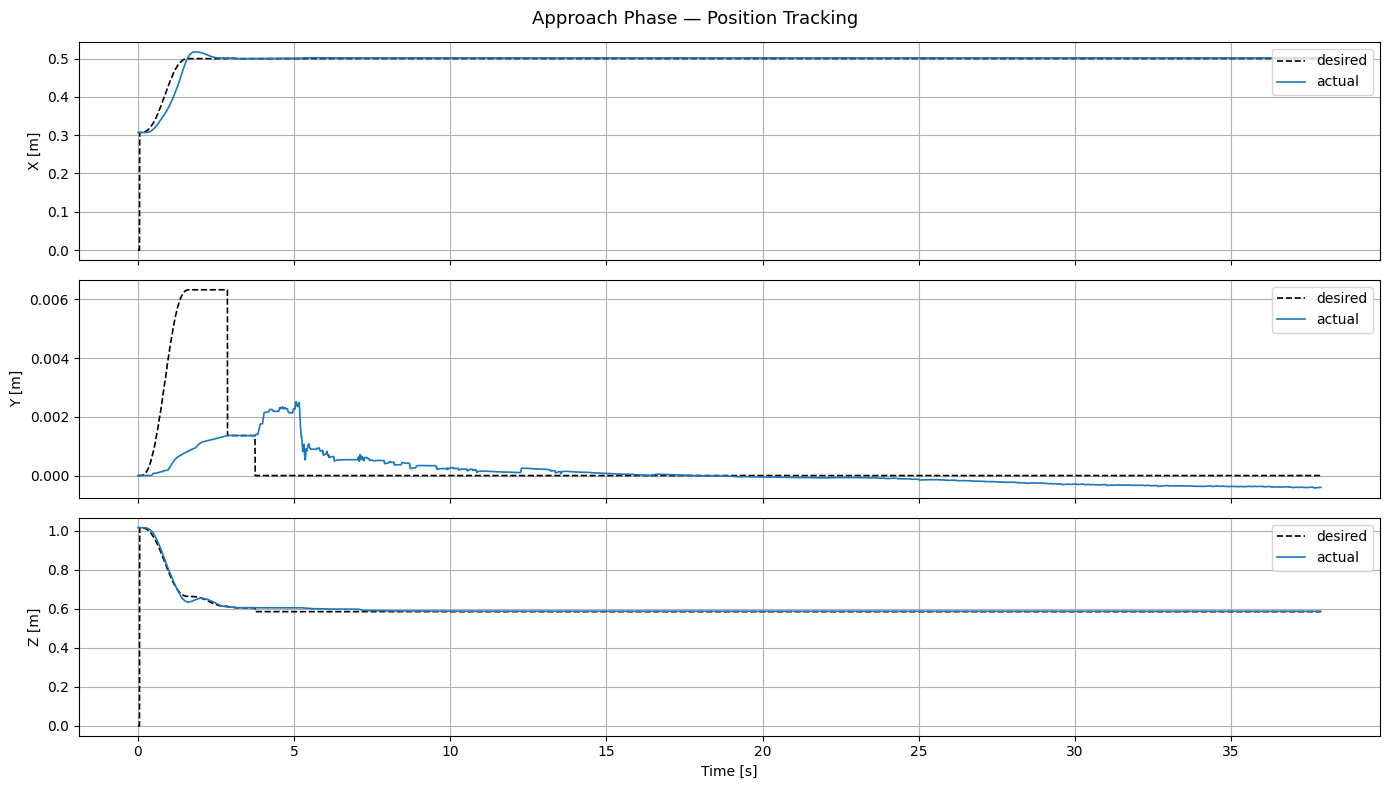

In [15]:
ctrl = bundles['ctrl_arm']
time = t(ctrl)

x_target  = np.array(ctrl['x_target'])   # (N, 7) — pos(3) + quat(4)
x_current = np.array(ctrl['x_current'])  # (N, 7) — pos(3) + quat(4)
p_des = x_target[:, :3]
p_act = x_current[:, :3]

labels = ['X', 'Y', 'Z']
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Approach Phase — Position Tracking', fontsize=13)

for i, ax in enumerate(axes):
    ax.plot(time, p_des[:, i], 'k--', label='desired', linewidth=1.2)
    ax.plot(time, p_act[:, i], label='actual', linewidth=1.2)
    ax.set_ylabel(f'{labels[i]} [m]')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

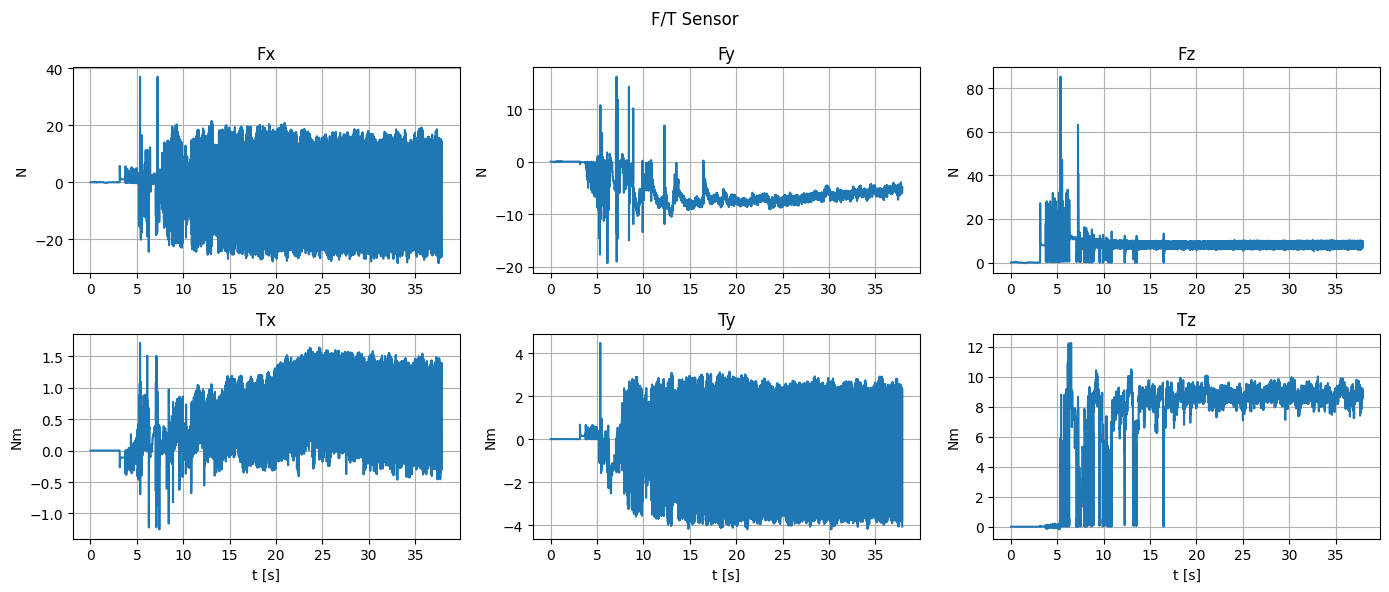

In [16]:
# --- F/T sensor ---
sensors = bundles['sensors']

ft_force  = sensors['ft_force']   # (N, 3)
ft_torque = sensors['ft_torque']  # (N, 3)
labels_f  = ['Fx', 'Fy', 'Fz']
labels_t  = ['Tx', 'Ty', 'Tz']

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i in range(3):
    axes[0, i].plot(t(sensors), ft_force[:, i])
    axes[0, i].set_title(labels_f[i])
    axes[0, i].set_ylabel('N')
    axes[1, i].plot(t(sensors), ft_torque[:, i])
    axes[1, i].set_title(labels_t[i])
    axes[1, i].set_ylabel('Nm')
    axes[1, i].set_xlabel('t [s]')
plt.suptitle('F/T Sensor')
plt.tight_layout()
plt.show()

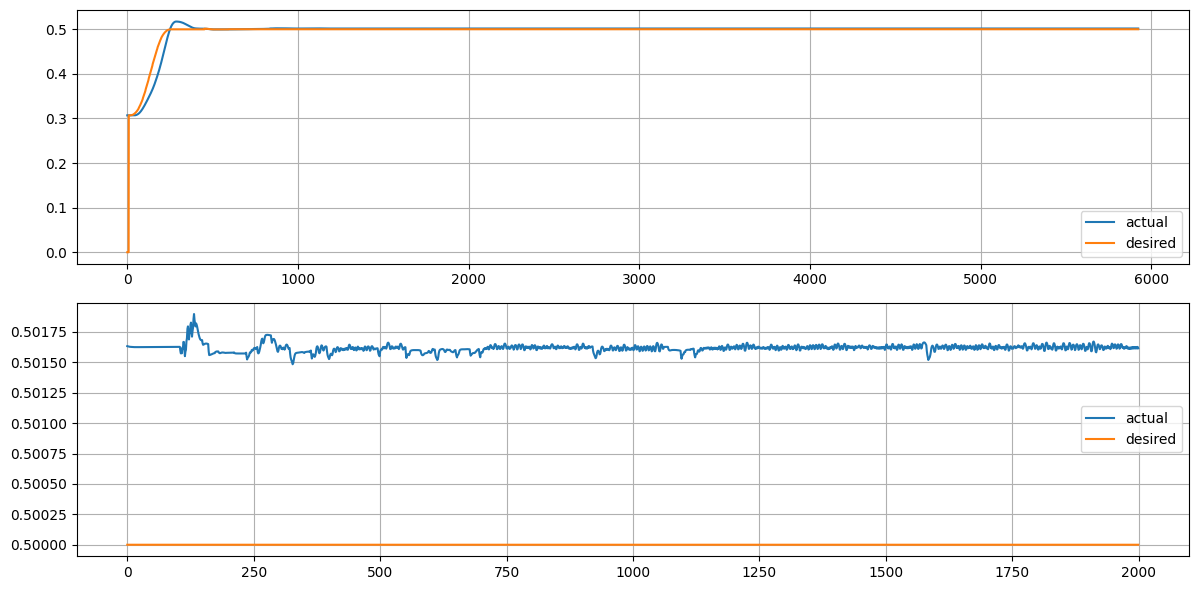

In [17]:
start, stop = 1000, 3000
idx = 0

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(p_act[:,idx], label='actual')
axes[0].plot(p_des[:,idx], label='desired')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(p_act[start:stop, idx], label='actual')
axes[1].plot(p_des[start:stop, idx], label='desired')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

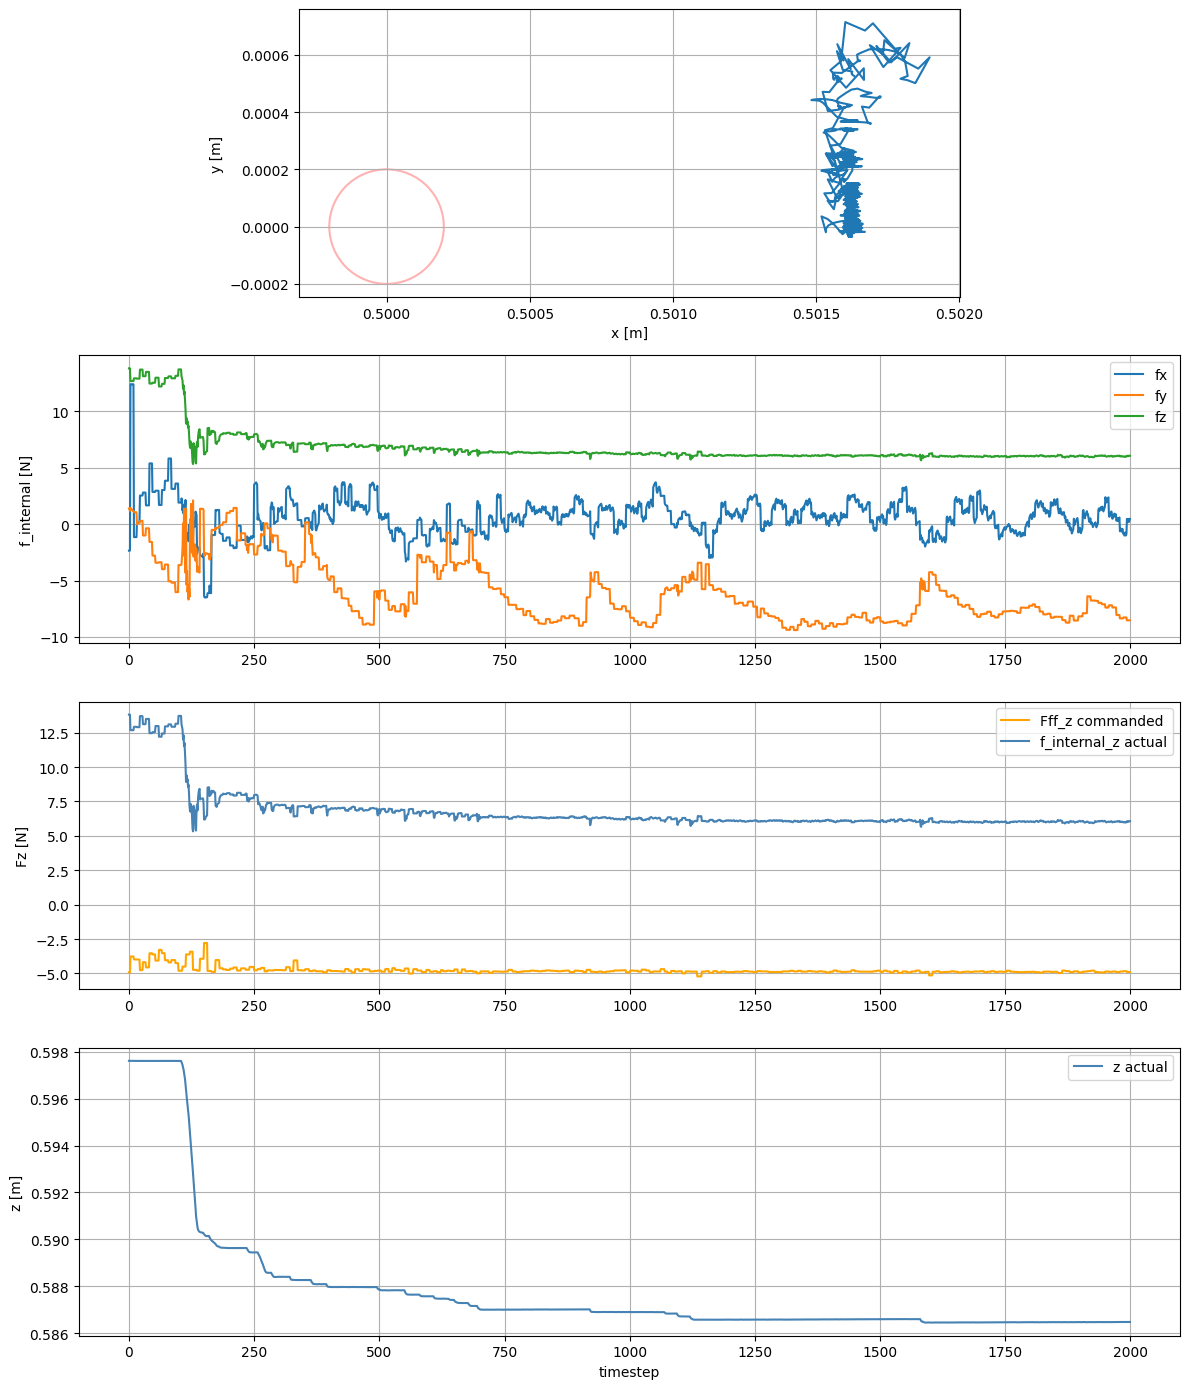

In [18]:
start, stop = 1000, 3000
fig, axes = plt.subplots(4, 1, figsize=(12, 14))

f_int = bundles["ctrl_arm"]["f_internal"][start:stop]
Fff   = bundles["ctrl_arm"]["Fff"][start:stop]
x_cur = bundles["ctrl_arm"]["x_current"][start:stop]

ax = axes[0]
ax.add_patch(plt.Circle((0.5, 0.0), 0.0002, color='red', alpha=0.3, fill=False, linewidth=1.5))
ax.plot(p_act[start:stop, 0], p_act[start:stop, 1])
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_aspect('equal')
ax.grid(True)

ax = axes[1]
ax.plot(f_int[:, 0], label="fx"); ax.plot(f_int[:, 1], label="fy"); ax.plot(f_int[:, 2], label="fz")
ax.set_ylabel("f_internal [N]"); ax.legend(); ax.grid(True)

ax = axes[2]
ax.plot(Fff[:, 2], label="Fff_z commanded", color="orange")
ax.plot(f_int[:, 2], label="f_internal_z actual", color="steelblue")
ax.set_ylabel("Fz [N]"); ax.legend(); ax.grid(True)

ax = axes[3]
ax.plot(x_cur[:, 2], label="z actual", color="steelblue")
ax.set_ylabel("z [m]"); ax.set_xlabel("timestep"); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

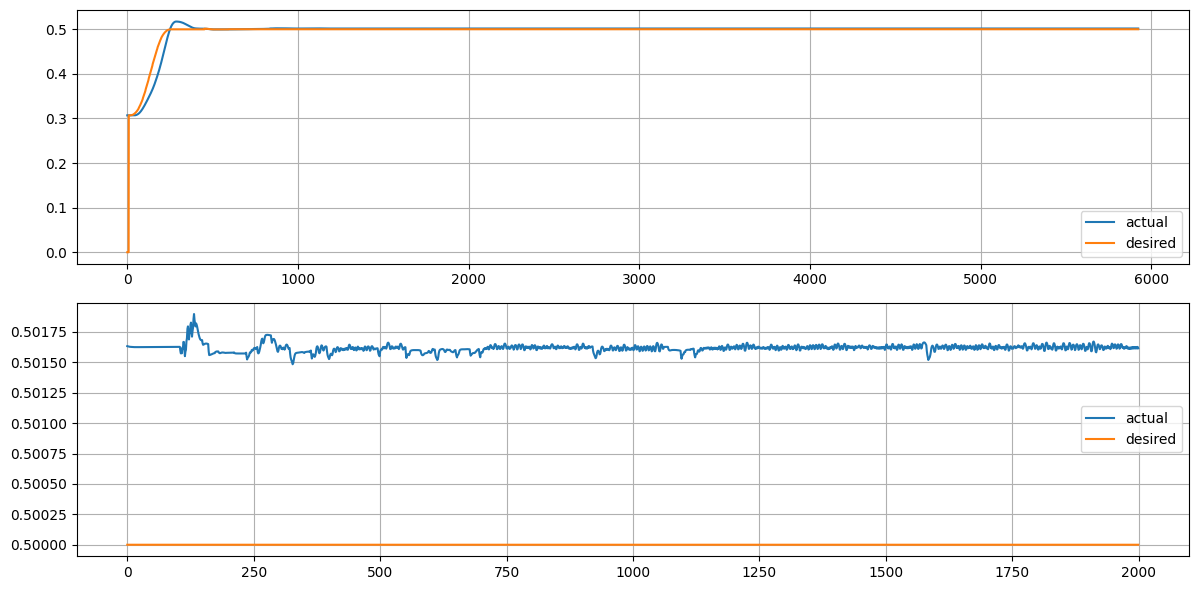

In [19]:
start, stop = 1000, 3000
idx = 0

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(p_act[:,idx], label='actual')
axes[0].plot(p_des[:,idx], label='desired')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(p_act[start:stop, idx], label='actual')
axes[1].plot(p_des[start:stop, idx], label='desired')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

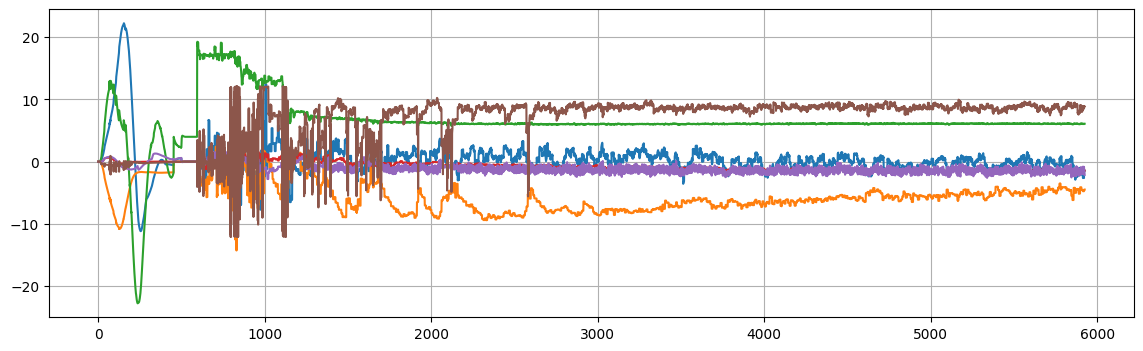

In [20]:
plt.plot(bundles["ctrl_arm"]["f_internal"])
plt.show()

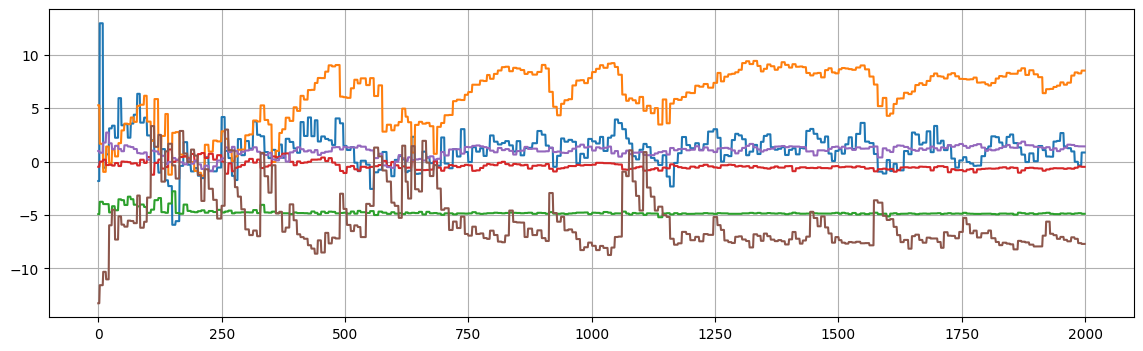

In [21]:
plt.plot(Fff)
plt.show()